In [2]:
# Q1. 이상거래로 판단되는 거래 ID를 추출하세요. 또한, 이상거래로 근거를 제시하세요.
## 거래시간과 구매금액, 사용앱, 기기 ID로 각각 특이점이 있는지 파악 
# Q2. 이상거래로 판단하기 위한 로직을 정의하고 설명

In [32]:
import pandas as pd
from matplotlib import pyplot as plt
plt.rc('font', family = 'Malgun Gothic')

In [33]:
df = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\플랫폼_거래.csv", encoding = 'euc-kr')

In [34]:
df.head()

,고객ID,거래ID,거래시간,구매금액(원),사용 앱,기기ID
0,A,T0001,2024-01-12 21:50:08,55900,app1,device2
1,A,T0002,2024-01-18 11:10:41,49600,app5,device1
2,A,T0003,2024-01-19 12:19:06,48800,app1,device2
3,A,T0004,2024-01-28 10:49:35,53200,app1,device2
4,A,T0005,2024-01-30 8:31:52,51300,app2,device1


In [35]:
df['거래시간'] = pd.to_datetime(df['거래시간'])

In [36]:
# 고객ID 기준 몇명이야? 분석해야할 고객수가.
customer_id_list = df['고객ID'].unique()
print(customer_id_list) # 총 5고객

['A' 'B' 'C' 'D' 'E']


In [37]:
# 이상거래 판단 근거 - 1. 거래시간
df['거래시각'] = df['거래시간'].dt.hour

In [21]:
# 하기에 쓰이는 for i, x in enumerate(): 테크닉 설명 (A ~ E를 0 ~ 4까지 숫자화) << 하나의 객채만 순회할때는 eunmerate를 습관적으로 써야한다 (??) - RE
for i, customer_id in enumerate(customer_id_list):
    print(i, customer_id)

0 A
1 B
2 C
3 D
4 E


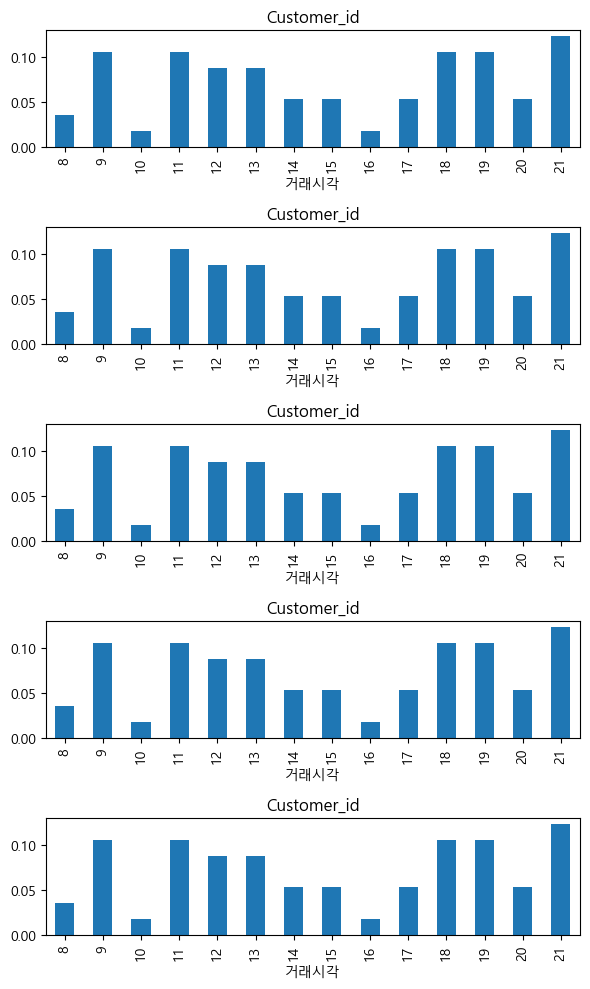

In [58]:
# subplots을 활용해서 index별 트렌드를 시각화 - fig, axes = 외우자 >> 이건 RE
fig, axes = plt.subplots(5,1, figsize = (6,10))
for i, customer_id in enumerate(customer_id_list): # I와 Customer_id가 동시에 변수조건으로 사용중
    customer_df = df.loc[df['고객ID'] == customer_id] # Raw 파일에는 고객 ID만 있다 > Customer_id로 영어변환해주고, Customer_df로 loc된것 추출
    customer_df['거래시각'].value_counts(normalize = True).sort_index().plot(kind = 'bar', ax = axes [i], title = 'Customer_id') #normalize True >비율
plt.tight_layout()

# Wow enumberate()를 plot함수와 연결시켜 변수에 맞춰 그래프 작성

In [59]:
# 윗 Customer_id 대신 A, B, C, D, E가 나와야하는데 잘 안 나왔는데, 실제 강의 데이터에는 C 고객에서 새벽 2시에 이상 거래가 발견
customer_df = df.loc[df['고객ID'] == 'C']
customer_df['거래시각'].value_counts(normalize = True).sort_index()

거래시각
2     0.018868
8     0.132075
9     0.018868
10    0.113208
12    0.056604
13    0.056604
14    0.056604
15    0.094340
16    0.056604
17    0.018868
18    0.094340
19    0.075472
20    0.132075
21    0.075472
Name: proportion, dtype: float64

In [41]:
customer_df.loc[df['거래시각'] == 2] # Potential 이상거래 (T0110) - 이 거래가 다른이상거래조건에도 맞는지 추가확인필요

,고객ID,거래ID,거래시간,구매금액(원),사용 앱,기기ID,거래시각
109,C,T0110,2024-02-04 02:07:12,116900,app1,device4,2


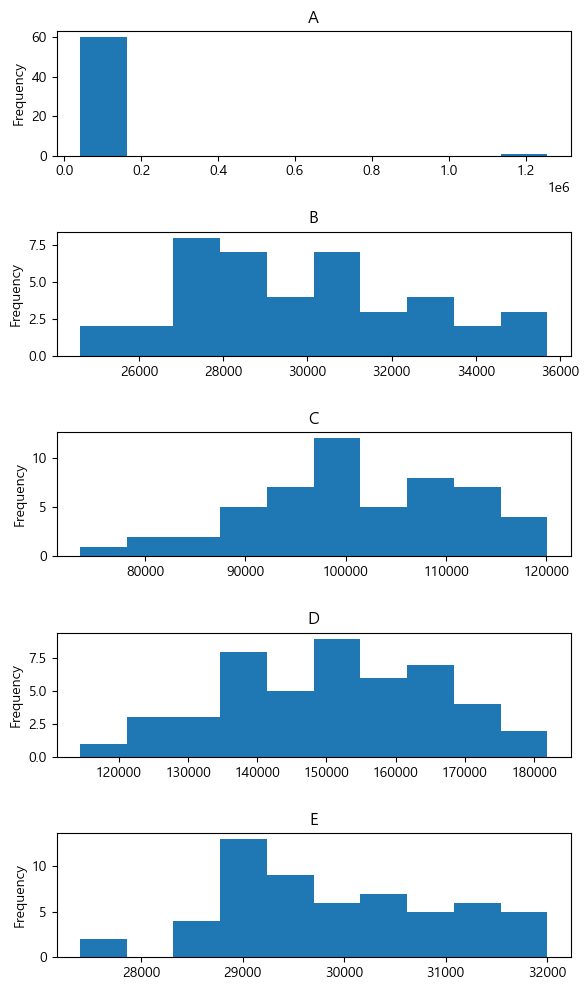

In [61]:
# 이상거래 판단 근거 - 2. 구매거래금액(원)
fix, axes = plt.subplots(5, 1, figsize = (6, 10))
for i, customer_id in enumerate(customer_id_list):
    customer_df = df.loc[df['고객ID'] == customer_id]
    customer_df['구매금액(원)'].plot(kind = 'hist', ax = axes [i], title = customer_id)
plt.tight_layout()
# 구매거래 금액기준(원) 기준으로는 A가 이상거래 가능성 있다. A hist 그래프 제일 마지막 금액은 1.2 1e6 인점 놓치면 안된다

In [54]:
df.groupby('고객ID')['구매금액(원)'].describe().round(0) # A가 이상거래 가능성 높다. Max값이 1,256,100원

,count,mean,std,min,25%,50%,75%,max
고객ID,,,,,,,,
A,61.0,70080.0,154460.0,41100.0,46500.0,50100.0,53500.0,1256100.0
B,42.0,29893.0,2773.0,24600.0,27700.0,29750.0,32050.0,35700.0
C,53.0,101091.0,10359.0,73500.0,94300.0,101100.0,108100.0,120100.0
D,48.0,150221.0,15699.0,114400.0,138300.0,151050.0,162100.0,181900.0
E,57.0,29881.0,1078.0,27400.0,29000.0,29700.0,30800.0,32000.0


In [55]:
customer_df = df.loc[df['고객ID'] == "A"]
customer_df.sort_values(by = '구매금액(원)', ascending = False).head() #T0022가 이상거래 가능성 높다

,고객ID,거래ID,거래시간,구매금액(원),사용 앱,기기ID,거래시각
21,A,T0022,2024-06-18 09:29:44,1256100,app5,device2,9
56,A,T0057,2024-12-11 14:48:51,61200,app4,device2,14
19,A,T0020,2024-06-05 20:13:28,59800,app1,device1,20
29,A,T0030,2024-07-24 19:25:37,59200,app4,device1,19
26,A,T0027,2024-07-14 08:53:01,59200,app2,device1,8


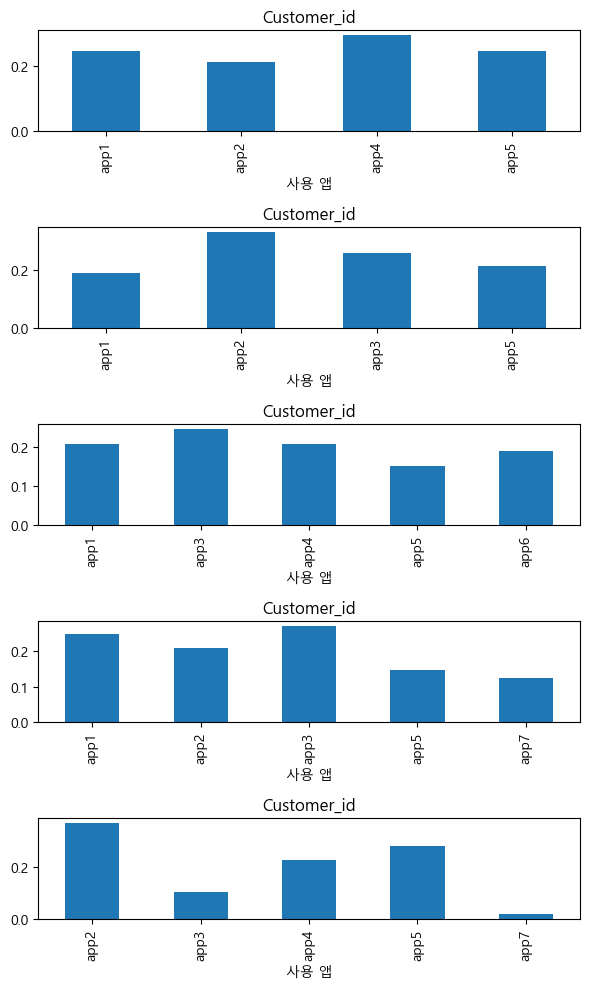

In [64]:
# 이상거래 판단 근거 - 3. 사용어플
fix, axes = plt.subplots(5, 1, figsize = (6, 10))
for i, customer_id in enumerate(customer_id_list):
    customer_df = df.loc[df['고객ID'] == customer_id]
    customer_df['사용 앱'].value_counts(normalize = True).sort_index().plot(kind = 'bar', ax = axes [i], title = 'Customer_id')
plt.tight_layout()
# 앱 사용기준으로는 E의 App7가 이상거래 가능성 있다. 

In [67]:
customer_df = df.loc[df['고객ID'] == 'E']
customer_df.loc[df['사용 앱'] == 'app7'] #T0258

,고객ID,거래ID,거래시간,구매금액(원),사용 앱,기기ID,거래시각
257,E,T0258,2024-12-05 18:14:14,30100,app7,device7,18


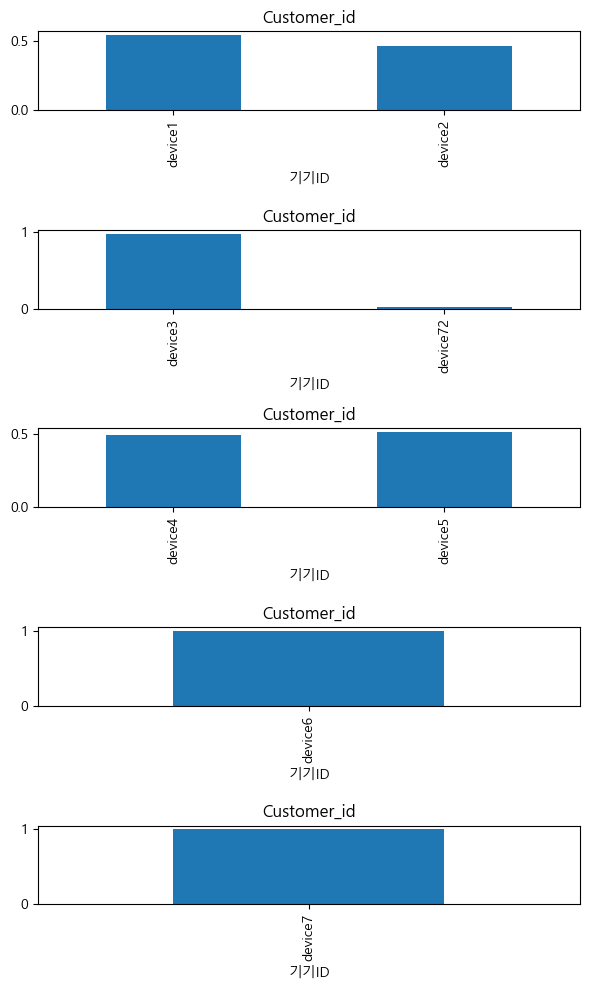

In [72]:
# 이상거래 판단 근거 - 4. 디바이스
fix, axes = plt.subplots(5, 1, figsize = (6, 10))
for i, customer_id in enumerate(customer_id_list):
    customer_df = df.loc[df['고객ID'] == customer_id]
    customer_df['기기ID'].value_counts(normalize = True).sort_index().plot(kind = 'bar', ax = axes [i], title = 'Customer_id')
plt.tight_layout()
# 앱 사용기준으로는 B의 Device72가 이상거래 가능성 있다. 

In [74]:
customer_df = df.loc[df['고객ID'] == 'B']
customer_df['기기ID'].value_counts(normalize = False) # False가 Defalut > 숫자 <> True: 비율

기기ID
device3     41
device72     1
Name: count, dtype: int64

In [75]:
customer_df.loc[df['기기ID'] == 'device72'] #T0102가 이상거래 가능성 있다

,고객ID,거래ID,거래시간,구매금액(원),사용 앱,기기ID,거래시각
101,B,T0102,2024-12-09 13:08:31,33100,app3,device72,13


In [137]:
# 이상거래 판단 근거 - 고난이도 응용 (연속거리 = 짧은 시간내 많은 거래가 발생하는 케이스) + 물리적인 지역과 시간이 또 다른 확인요소가 될수 있다 
for i, customer_id in enumerate(customer_id_list):
    customer_df = df.loc[df['고객ID'] == customer_id]
    print(customer_id)
    display(customer_df['거래시간'].diff().describe()) # 거래가 시간 차이를 보기위해 diff() 사용.
    print('\n')
# D의 Min을 보면 거래간 간격이 1초다. 이상거래 확인필요.

A


count                           60
mean     5 days 16:43:27.866666666
std      5 days 11:04:39.716934609
min                0 days 20:06:10
25%                2 days 12:04:55
50%         3 days 15:30:57.500000
75%                6 days 18:41:06
max               32 days 02:15:09
Name: 거래시간, dtype: object



B


count                            41
mean      8 days 17:32:46.829268292
std      10 days 01:02:15.697191659
min                 0 days 19:00:58
25%                 2 days 05:54:30
50%                 4 days 06:37:53
75%                10 days 11:15:33
max                49 days 01:36:42
Name: 거래시간, dtype: object



C


count                           52
mean     6 days 22:21:20.942307692
std      8 days 05:18:33.598241123
min                0 days 13:02:07
25%         2 days 06:26:20.500000
50%                4 days 15:12:45
75%         8 days 21:13:09.750000
max               40 days 14:05:22
Name: 거래시간, dtype: object



D


count                           47
mean     7 days 17:21:48.361702127
std      7 days 05:28:26.935942422
min                0 days 00:00:01
25%                2 days 09:15:42
50%                4 days 12:53:10
75%        12 days 11:04:04.500000
max               26 days 20:27:29
Name: 거래시간, dtype: object



E


count                           56
mean     6 days 08:16:21.910714285
std      4 days 14:10:27.359870802
min                0 days 19:57:31
25%         2 days 22:11:21.750000
50%         5 days 16:07:07.500000
75%                8 days 17:02:20
max               24 days 07:00:43
Name: 거래시간, dtype: object

In [79]:
df.loc[df['고객ID'] == "D", '거래시간'].diff()
# 167과 168열이 1초다. 보기가 어렵다 > idxmin()사용하여 min. 추출

156                NaT
157    8 days 15:46:39
158   25 days 10:20:32
159    8 days 13:00:36
160    2 days 06:07:30
161    2 days 20:53:19
162    1 days 20:47:21
163    2 days 11:25:44
164   23 days 13:43:22
165   13 days 00:47:18
166   12 days 09:45:44
167    0 days 00:00:01
168    0 days 00:00:01
169   15 days 10:43:10
170    4 days 12:53:10
171   21 days 21:00:33
172    9 days 16:38:09
173    3 days 10:21:03
174    2 days 12:24:27
175    3 days 23:22:21
176   14 days 05:35:22
177    0 days 21:17:53
178    1 days 06:50:50
179    1 days 23:44:37
180   17 days 03:16:52
181   12 days 23:42:00
182    6 days 18:13:34
183    7 days 21:47:53
184    6 days 00:33:40
185    4 days 23:53:57
186   14 days 03:55:17
187    2 days 03:37:38
188   12 days 12:22:25
189    3 days 09:56:00
190    8 days 21:01:04
191    3 days 19:28:47
192    2 days 07:05:40
193    3 days 20:54:02
194   26 days 20:27:29
195    3 days 08:03:13
196   21 days 14:28:00
197    1 days 06:33:44
198    3 days 04:05:29
199    0 da

In [81]:
print(df.loc[df['고객ID'] == "D", '거래시간'].diff().idxmin())

167


In [84]:
# 이상거래 근처값 확인
df.loc[166:170] # 166 ~ 168번까지가 너무 짧은시간내 같은 ID인데, 사용App이 다르다... 기기가 같아서 가능은 사이간극이 너무 짧다?

,고객ID,거래ID,거래시간,구매금액(원),사용 앱,기기ID,거래시각
166,D,T0167,2024-04-11 21:20:54,176900,app2,device6,21
167,D,T0168,2024-04-11 21:20:55,142800,app5,device6,21
168,D,T0169,2024-04-11 21:20:56,132700,app3,device6,21
169,D,T0170,2024-04-27 08:04:06,156000,app7,device6,8
170,D,T0171,2024-05-01 20:57:16,166400,app5,device6,20


In [91]:
# Q2. 이상거래로 판단하기 위한 로직 정의

# 로직이 각 고객마다 작동하게 만들기 위해 사전작업
df_A = df.loc[df['고객ID'] == 'A']
df_B = df.loc[df['고객ID'] == 'B']
df_C = df.loc[df['고객ID'] == 'C']
df_D = df.loc[df['고객ID'] == 'D']
df_E = df.loc[df['고객ID'] == 'E']

In [109]:
# 거래시각 기준 이상거래 탐지 >> 이해못했다(1/6)
def rare_hour_check(customer_df):
    output = []
    #빈도가 가장 낮은 거래 시각 가운데, 근처 시간에도 거래가 없는경우를 이상거래로 정의
    vc = customer_df['거래시각'].value_counts(normalize = True)
    min_val = vc.min() # 가장 작은 값이 이상값이 가능성이 높다
    if min_val < 0.05: # 5% 미만
        min_val_hour_list = vc.loc[vc == vc.min()].index # 빈도가 가장 작은 값을 Unique값으로 filter하고 index (거래가 일어난 시간대)를 가져온다
        for min_val_hour in min_val_hour_list: # min_valu hour를 순회하면서
            prev_hour = min_val_hour - 1 # prev. hour 정의
            next_hour = min_val_hour + 1 # next. hour 정의
            if prev_hour == -1: #24시간 구조때문에 - 이슈 생길수 있으니 보정
                prev_hour = 23
            if next_hour == 24:
                next_hour = 0

            if (prev_hour not in vc.index) and (next_hour not in vc.index):
                output = customer_df.loc[customer_df['거래시각'] == min_val_hour, '거래ID'].tolist()
    return output

In [110]:
print(rare_hour_check(df_A))
print(rare_hour_check(df_B))
print(rare_hour_check(df_C))
print(rare_hour_check(df_D))
print(rare_hour_check(df_E))

[]
[]
['T0110']
[]
[]


In [116]:
# 거래금액 기반
def large_amount_check(customer_df):
    Q1, Q3 = customer_df['구매금액(원)'].quantile([0.25, 0.75]).tolist() # 투플의 특이한 구조 > Q1는 0.25에, Q3는 0.75에 매핑된 구조; 왜 했어? IQR쓰려고
    IQR = Q3 - Q1 #IQR는 그냥 공식처럼 쓰여진 케이스
    output = customer_df.loc[customer_df['구매금액(원)'] > Q3 + 1.5 * IQR, '거래ID'].tolist()
    return output

In [117]:
print(large_amount_check(df_A))
print(large_amount_check(df_B))
print(large_amount_check(df_C))
print(large_amount_check(df_D))
print(large_amount_check(df_E))

['T0022']
[]
[]
[]
[]


In [124]:
# App 기반
def rare_app_check(customer_df):
    output = []
    vc = customer_df['사용 앱'].value_counts()
    min_val = vc.min()
    if min_val == 1: # 1회만 쓰인경우 일단 의심
        first_used_app_list = vc.loc[vc == min_val].index
        output = customer_df.loc[customer_df['사용 앱'].isin(first_used_app_list), '거래ID'].tolist()
    return output        


In [125]:
print(rare_app_check(df_A))
print(rare_app_check(df_B))
print(rare_app_check(df_C))
print(rare_app_check(df_D))
print(rare_app_check(df_E))

[]
[]
[]
[]
['T0258']


In [130]:
# 디바이스 기반
def rare_device_check(customer_df):
    output = []
    vc = customer_df['기기ID'].value_counts()
    min_val = vc.min()
    if min_val == 1:
        first_used_app_list = vc.loc[vc == min_val].index
        output = customer_df.loc[customer_df['기기ID'].isin(first_used_app_list), '거래ID'].tolist
    return output

In [131]:
print(rare_device_check(df_A))
print(rare_device_check(df_B))
print(rare_device_check(df_C))
print(rare_device_check(df_D))
print(rare_device_check(df_E))

[]
<bound method IndexOpsMixin.tolist of 101    T0102
Name: 거래ID, dtype: object>
[]
[]
[]


In [132]:
# 연속거래로. 거래간 간격이 30초보다 적은 거래는 이상거래로 의심해보자
def transaction_check(customer_df):
    transaction_check = customer_df.loc[customer_df['거래시간'].diff().dt.seconds < 30, '거래ID'].tolist()
    return transaction_check

In [133]:
print(transaction_check(df_A))
print(transaction_check(df_B))
print(transaction_check(df_C))
print(transaction_check(df_D))
print(transaction_check(df_E))

[]
[]
[]
['T0168', 'T0169']
[]
